# Notebook 4 — Optimisation & interprétabilité

Le notebook 3 a identifié LightGBM comme modèle champion. Ce notebook va plus
loin :

1. **Optimisation des hyperparamètres** avec Optuna (objectif : AUC par CV)
2. **Seuil de décision métier** : on ne garde pas 0.5 par défaut — on cherche
   le seuil qui minimise le coût métier (FN × 10 + FP × 1)
3. **Feature importance globale** : quelles variables comptent le plus en général ?
4. **Interprétabilité locale** (SHAP) : pourquoi le modèle prédit ce résultat
   pour un client donné ?

In [1]:
import sys
sys.path.insert(0, '..')
from src.modelization import cout_metier, trouver_seuil_optimal
from src.preprocessing import build_preprocessor
from src.visualizer import create_lineplot, create_barh
from src.utils import distribution_column

import mlflow
import optuna
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, recall_score
from lightgbm import LGBMClassifier
from mlflow.sklearn import log_model as mlflow_log_model


RANDOM_STATE = 42
# Réduire le verbosity d'Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit-scoring")

<Experiment: artifact_location='/home/rapha/ai-engineer/credit-scoring-mlops/mlruns', creation_time=1773648058682, experiment_id='1', last_update_time=1773648058682, lifecycle_stage='active', name='credit-scoring', tags={}, workspace='default'>

## Chargement des données

Je recharge le dataset prétraité et je sépare immédiatement un jeu de validation
(`X_val`) qui ne sera jamais utilisé pendant l'optimisation — pour éviter tout
data leakage.

In [2]:
df_train = pd.read_csv("../data/processed/train_processed.csv")

X = df_train.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_train["TARGET"]

# Split train/validation — fait EN PREMIER avant toute optimisation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape[0]} lignes | Validation : {X_val.shape[0]} lignes")
print(f"Distribution cible (train) :\n{y_train.value_counts(normalize=True).round(3)}")

distribution_column(pd.DataFrame({'TARGET': y}), 'TARGET')

Train : 246008 lignes | Validation : 61503 lignes
Distribution cible (train) :
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

📊 Distribution de la colonne 'TARGET'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
TARGET,,
0,282686,91.93
1,24825,8.07


In [3]:
# Identification des types de colonnes
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Colonnes numériques   : {len(num_cols)}')
print(f'Colonnes catégorielles : {len(cat_cols)}')

Colonnes numériques   : 99
Colonnes catégorielles : 13


## Optimisation des hyperparamètres avec Optuna

Plutôt qu'une grille exhaustive (GridSearch), j'utilise Optuna qui explore les
hyperparamètres de façon intelligente (TPE — optimisation bayésienne). Il apprend
des essais précédents pour concentrer la recherche là où c'est prometteur.

**Objectif : maximiser l'AUC** par validation croisée 3 folds, uniquement sur
`X_train`. `X_val` n'est jamais utilisé pendant l'optimisation.

### Hyperparamètres optimisés — définitions simples

- **`n_estimators`** : nombre d'arbres construits. Plus il y en a, plus le modèle est précis — mais plus long à entraîner.
- **`learning_rate`** : vitesse d'apprentissage à chaque étape. Petit = plus prudent (moins d'overfitting), mais nécessite plus d'arbres.
- **`num_leaves`** : nombre de feuilles par arbre. Plus élevé = arbre plus complexe, capable de capter des patterns fins — mais risque d'overfitting.
- **`min_child_samples`** : nombre minimum d'exemples dans une feuille. Garde-fou contre l'overfitting : une feuille avec trop peu de données est suspecte.
- **`reg_alpha`** : régularisation L1 — pousse certains poids à zéro → modèle plus "épuré".
- **`reg_lambda`** : régularisation L2 — pénalise les poids trop grands → réduit l'écart entre train et validation.

In [4]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

def objective(trial):
    """Fonction objectif Optuna — maximise l'AUC par CV 3 folds sur X_train.

    X_val n'est jamais utilisé ici, ce qui évite le data leakage.
    Optuna minimise → on retourne l'opposé de l'AUC.
    """
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600, step=100),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }

    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(num_cols, cat_cols)),
        ('clf', LGBMClassifier(
            **params,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ))
    ])

    # CV 3 folds sur X_train uniquement — X_val n'est jamais vu pendant l'optimisation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
    return -scores.mean()  # Optuna minimise → on retourne l'opposé de l'AUC


study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

best_auc_cv = -study.best_value
print(f"\nMeilleure AUC (CV) : {best_auc_cv:.4f}")
print(f"Meilleurs paramètres : {study.best_params}")

  0%|          | 0/15 [00:00<?, ?it/s]


Meilleure AUC (CV) : 0.7716
Meilleurs paramètres : {'n_estimators': 400, 'learning_rate': 0.017398074711291726, 'num_leaves': 98, 'min_child_samples': 49, 'reg_alpha': 0.32808889626606236, 'reg_lambda': 0.14408501080722544}


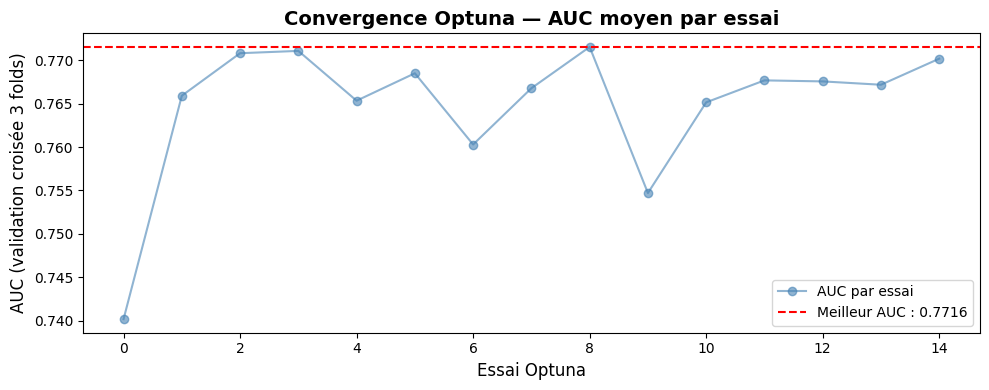

In [5]:
# Courbe de convergence d'Optuna — AUC par essai
trials_df = study.trials_dataframe()
auc_values = -trials_df['value']  # reconversion en AUC positif (Optuna stocke -AUC)

fig, ax = plt.subplots(figsize=(10, 4))
create_lineplot(
    ax,
    x=trials_df['number'], y=auc_values,
    marker='o', alpha=0.6,
    label='AUC par essai',
    hline=best_auc_cv, hline_label=f'Meilleur AUC : {best_auc_cv:.4f}',
    xlabel='Essai Optuna',
    ylabel='AUC (validation croisée 3 folds)',
    title='Convergence Optuna — AUC moyen par essai',
)
plt.tight_layout()
plt.savefig('../data/processed/optuna_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Entraînement du modèle final

J'entraîne LightGBM avec les meilleurs hyperparamètres trouvés par Optuna, puis
je calcule les probabilités de défaut sur `X_val` pour évaluer le seuil de
décision.

In [6]:
# Entraînement avec les meilleurs hyperparamètres trouvés par Optuna
best_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, cat_cols)),
    ('clf', LGBMClassifier(
        **study.best_params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ))
])

best_pipeline.fit(X_train, y_train)
y_pred_proba = best_pipeline.predict_proba(X_val)[:, 1]

print("Modèle final entraîné.")

Modèle final entraîné.


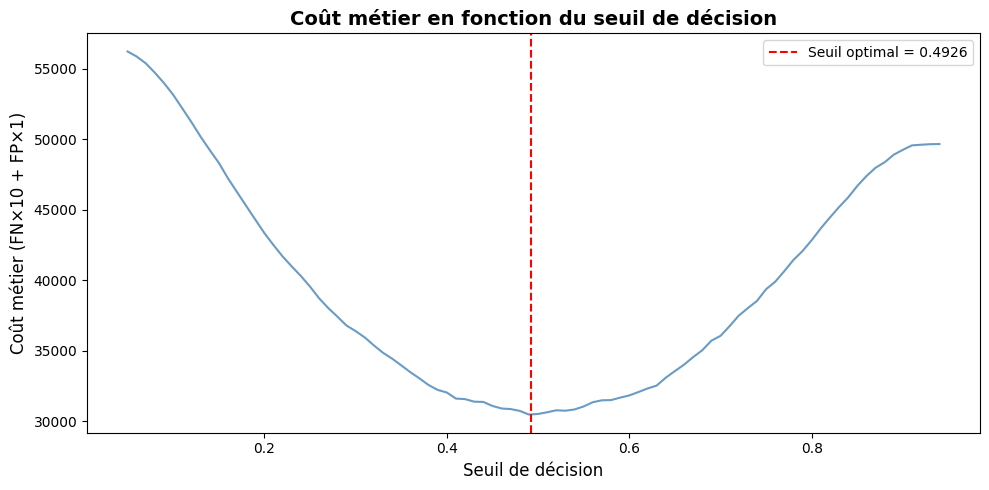

Seuil optimal : 0.4926 | Coût métier minimal : 30,415


In [7]:
# Recherche du seuil optimal et tracé de la courbe coût vs seuil
seuils = np.arange(0.05, 0.95, 0.01)
couts  = [cout_metier(y_val, y_pred_proba, seuil=s) for s in seuils]

seuil_opt, cout_opt = trouver_seuil_optimal(y_val, y_pred_proba)

fig, ax = plt.subplots(figsize=(10, 5))
create_lineplot(
    ax,
    x=seuils, y=couts,
    vline=seuil_opt, vline_label=f'Seuil optimal = {seuil_opt}',
    xlabel='Seuil de décision',
    ylabel='Coût métier (FN×10 + FP×1)',
    title='Coût métier en fonction du seuil de décision',
)
plt.tight_layout()
plt.savefig('../data/processed/courbe_seuil.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Seuil optimal : {seuil_opt} | Coût métier minimal : {cout_opt:,}")

In [8]:
# Métriques finales
y_pred_final = (y_pred_proba >= seuil_opt).astype(int)
roc_auc_final    = roc_auc_score(y_val, y_pred_proba)
recall_final = recall_score(y_val, y_pred_final)

with mlflow.start_run(run_name='lgbm_optimized') as run:
    # Paramètres
    mlflow.log_params(study.best_params)
    mlflow.log_param('n_trials_optuna', 15)
    mlflow.log_param('cv_folds_optuna', 3)
    mlflow.log_metric('seuil_optimal', float(seuil_opt))

    # Métriques
    mlflow.log_metric('roc_auc', round(float(roc_auc_final), 4))
    mlflow.log_metric('roc_auc_cv_optuna', round(float(best_auc_cv), 4))
    mlflow.log_metric('cout_metier', float(cout_opt))
    mlflow.log_metric('recall_classe_1', round(float(recall_final), 4))

    # Artefacts
    mlflow.log_artifact('../data/processed/courbe_seuil.png')
    mlflow.log_artifact('../data/processed/optuna_convergence.png')

    # Modèle — pyfunc_predict_fn="predict_proba" pour que le serving retourne des probabilités
    mlflow_log_model(best_pipeline, name='model', pyfunc_predict_fn="predict_proba")
    mlflow.set_tag('dataset', 'full')
    mlflow.set_tag('etape', 'optimisation')

    run_id = run.info.run_id

print(f"AUC (val)       : {roc_auc_final:.4f}")
print(f"AUC (CV Optuna) : {best_auc_cv:.4f}")
print(f"Recall classe 1 : {recall_final:.4f}")
print(f"Coût métier (seuil={seuil_opt}) : {cout_opt:,}")
print(f"run_id : {run_id}")

2026/03/20 11:27:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/20 11:27:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


AUC (val)       : 0.7782
AUC (CV Optuna) : 0.7716
Recall classe 1 : 0.6866
Coût métier (seuil=0.4926) : 30,415
run_id : 6a9a2b40c4a9469099a91afbda14378f


## Matrice de confusion au seuil optimal

Concrètement, combien de clients sont mal classés au seuil retenu ?

- **FN** (mauvais client prédit bon → crédit accordé) : coût × 10
- **FP** (bon client prédit mauvais → crédit refusé) : coût × 1

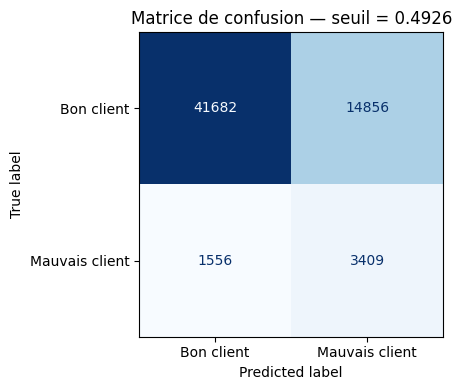

FN (mauvais prédit bon)  : 1,556  → coût = 15,560
FP (bon prédit mauvais)  : 14,856  → coût = 14,856
Coût total               : 30,416


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=["Bon client", "Mauvais client"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matrice de confusion — seuil = {seuil_opt}")
plt.tight_layout()
plt.show()

print(f"FN (mauvais prédit bon)  : {fn:,}  → coût = {fn * 10:,}")
print(f"FP (bon prédit mauvais)  : {fp:,}  → coût = {fp:,}")
print(f"Coût total               : {fn * 10 + fp:,}")

## Comparaison avec le modèle de référence

On compare ici les métriques du modèle LightGBM **sans optimisation** (notebook 3, CV 5-fold)
avec celles du modèle **optimisé par Optuna** (notebook 4, jeu de validation).

> **Note :** Les métriques du baseline sont issues d'une validation croisée 5-fold sur tout le
> dataset d'entraînement. Celles du modèle optimisé sont calculées sur `X_val` (20% non vus
> pendant l'optimisation). Les deux sont comparables mais pas strictement identiques.

In [10]:
# Récupération des métriques du modèle de référence depuis MLflow (notebook 3)
runs_baseline: pd.DataFrame = mlflow.search_runs(  # type: ignore[assignment]
    experiment_names=["credit-scoring"],
    filter_string="tags.mlflow.runName = 'lightgbm'",
    order_by=["start_time DESC"],
    max_results=1,
    output_format="pandas",
)
baseline = runs_baseline.iloc[0]

# Tableau de comparaison
df_compare = pd.DataFrame({
    "Modèle":       ["LightGBM baseline (nb. 3)", "LightGBM optimisé (nb. 4)"],
    "AUC":          [baseline["metrics.roc_auc_test_mean"], roc_auc_final],
    "Recall cl. 1": [baseline["metrics.recall_test_mean"],  recall_final],
    "Coût métier":  [baseline["metrics.cout_metier"],       cout_opt],
    "Seuil":        [baseline["metrics.seuil_optimal"],     seuil_opt],
}).set_index("Modèle").round(4)

df_compare

,AUC,Recall cl. 1,Coût métier,Seuil
Modèle,,,,
LightGBM baseline (nb. 3),0.7709,0.6604,30779.0,0.5514
LightGBM optimisé (nb. 4),0.7782,0.6866,30415.0,0.4926


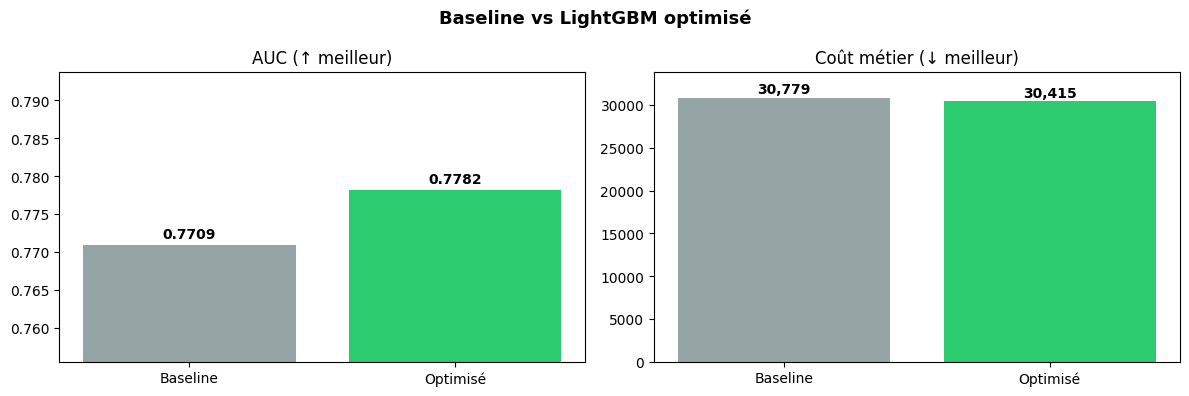

In [11]:
# Graphique comparatif — AUC et Coût métier (les deux métriques clés)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modeles_labels = ["Baseline", "Optimisé"]
couleurs = ["#95a5a6", "#2ecc71"]

# AUC (↑ meilleur)
axes[0].bar(modeles_labels, df_compare["AUC"], color=couleurs)
axes[0].set_title("AUC (↑ meilleur)")
axes[0].set_ylim(df_compare["AUC"].min() * 0.98, df_compare["AUC"].max() * 1.02)
for i, v in enumerate(df_compare["AUC"]):
    axes[0].text(i, v + 0.0005, f"{v:.4f}", ha="center", va="bottom", fontweight="bold")

# Coût métier (↓ meilleur)
axes[1].bar(modeles_labels, df_compare["Coût métier"], color=couleurs)
axes[1].set_title("Coût métier (↓ meilleur)")
axes[1].set_ylim(0, df_compare["Coût métier"].max() * 1.1)
for i, v in enumerate(df_compare["Coût métier"]):
    axes[1].text(i, v + 200, f"{v:,.0f}", ha="center", va="bottom", fontweight="bold")

fig.suptitle("Baseline vs LightGBM optimisé", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature importance globale

Quelles variables le modèle utilise-t-il le plus pour prendre ses décisions ?
LightGBM calcule une importance intrinsèque basée sur le nombre de fois qu'une
feature est utilisée pour faire un split.

C'est une vue d'ensemble utile, mais elle ne dit pas dans quel sens chaque
feature influence la prédiction — c'est le rôle de SHAP dans la section suivante.

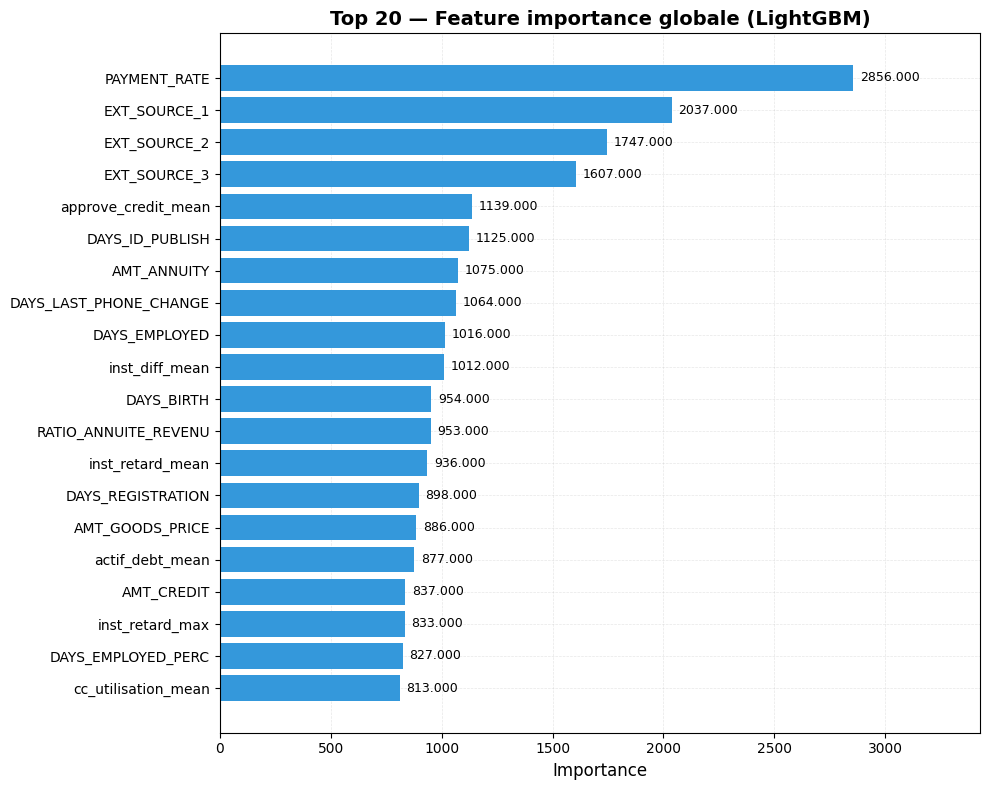

In [12]:
# Récupération du classifieur et des noms de features après transformation
clf = best_pipeline.named_steps['clf']

ohe_features = (
    best_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_features = num_cols + ohe_features

# Top 20 features par importance
importances = pd.Series(clf.feature_importances_, index=all_features)
top20 = importances.nlargest(20).sort_values().reset_index()
top20.columns = ['feature', 'importance']

fig, ax = plt.subplots(figsize=(10, 8))
create_barh(
    top20, ax,
    x='importance', y='feature',
    sort=False,  # déjà trié par nlargest().sort_values()
    title='Top 20 — Feature importance globale (LightGBM)',
    xlabel='Importance',
)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_globale.png', dpi=150, bbox_inches='tight')
plt.show()

# Ajout de l'artefact au run MLflow existant
with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact('../data/processed/feature_importance_globale.png')

## Interprétabilité locale avec SHAP

L'importance globale dit "cette variable compte beaucoup". SHAP va plus loin :
il explique **pourquoi le modèle a prédit ce score pour ce client précis**.

Chaque feature reçoit une valeur SHAP :
- **positive** → pousse la probabilité vers le défaut
- **négative** → pousse vers le remboursement

Je montre trois profils : un client à risque élevé, un client à faible risque,
et un cas médian.

/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


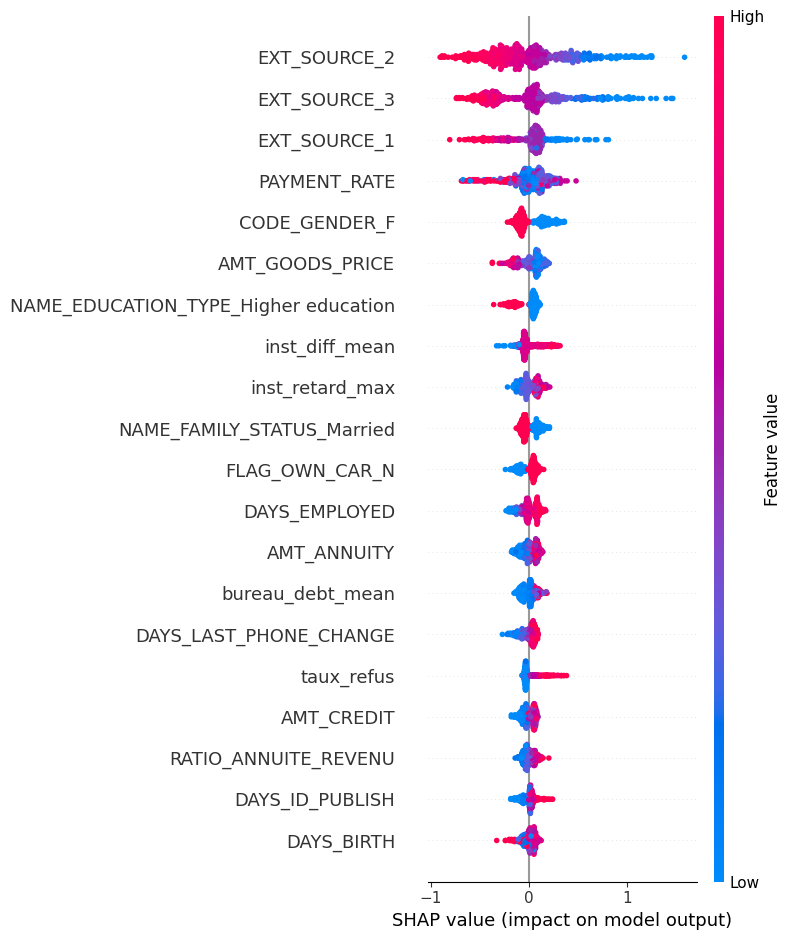

In [13]:
# Transformation des données de validation par le preprocesseur
X_val_transformed = best_pipeline.named_steps['preprocessor'].transform(X_val)

# Sous-échantillon de 500 clients pour accélérer le calcul SHAP
rng = np.random.default_rng(RANDOM_STATE)
idx_shap = rng.choice(len(X_val_transformed), size=500, replace=False)
X_shap   = X_val_transformed[idx_shap]

# Explainer SHAP pour modèles à base d'arbres
explainer  = shap.TreeExplainer(clf)
shap_vals  = explainer.shap_values(X_shap)

# Pour la classification binaire, shap_values peut retourner une liste [classe_0, classe_1]
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]  # classe positive = défaut de paiement

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

# Graphique beeswarm — distribution des impacts de chaque feature
plt.figure()
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=all_features,
    max_display=20,
    show=False,
)
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

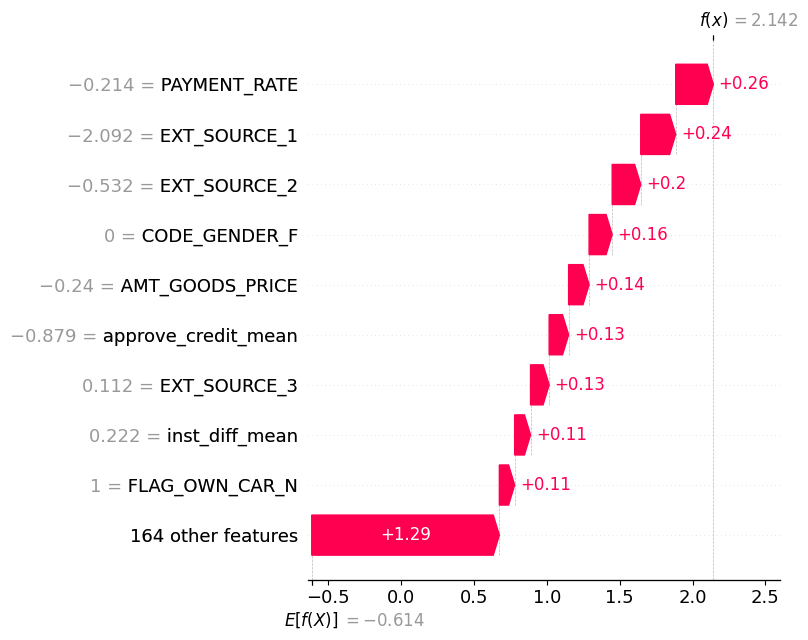

client_risque_eleve — proba défaut : 0.895


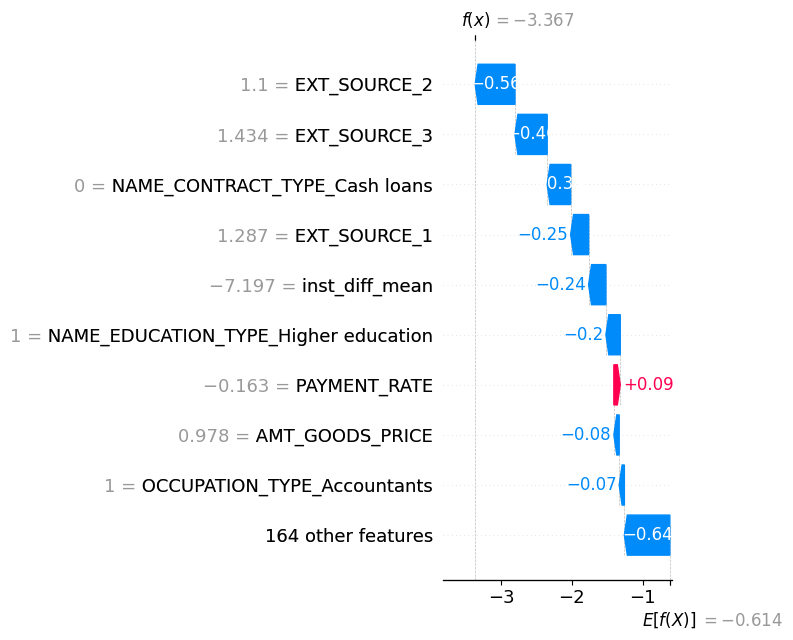

client_faible_risque — proba défaut : 0.033


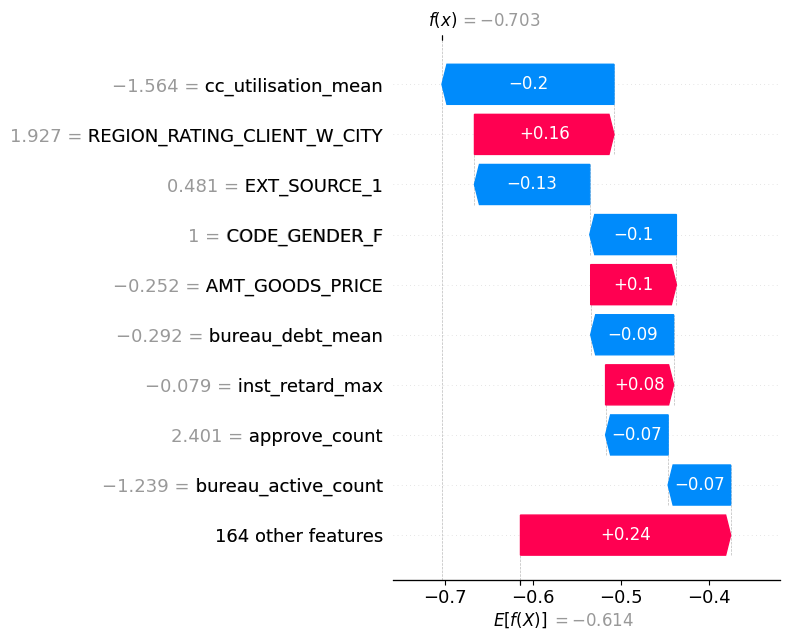

client_median — proba défaut : 0.331


In [14]:
# Probabilités de défaut sur le sous-échantillon SHAP
y_proba_shap = y_pred_proba[idx_shap]

# 3 profils clients représentatifs
idx_haut = y_proba_shap.argmax()                                   # risque élevé
idx_bas  = y_proba_shap.argmin()                                   # faible risque
idx_med  = np.abs(y_proba_shap - np.median(y_proba_shap)).argmin() # cas médian

profils = [
    ('client_risque_eleve',  idx_haut),
    ('client_faible_risque', idx_bas),
    ('client_median',        idx_med),
]

for label, idx in profils:
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[idx],
            base_values=base_val,
            data=X_shap[idx],
            feature_names=all_features,
        ),
        show=False,
    )
    plt.tight_layout()
    plt.savefig(f'../data/processed/shap_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{label} — proba défaut : {y_proba_shap[idx]:.3f}")

In [15]:
# Logging de tous les artefacts SHAP dans le run MLflow existant
artefacts_shap = [
    '../data/processed/shap_beeswarm.png',
    '../data/processed/shap_client_risque_eleve.png',
    '../data/processed/shap_client_faible_risque.png',
    '../data/processed/shap_client_median.png',
]

with mlflow.start_run(run_id=run_id):
    for path in artefacts_shap:
        mlflow.log_artifact(path)

print("Artefacts SHAP loggés dans MLflow.")

Artefacts SHAP loggés dans MLflow.


## Enregistrement du modèle dans le MLflow Registry

On enregistre le modèle optimisé dans le registry MLflow sous le nom `credit-scoring-model`
et on lui assigne l'alias `production`. Cela permet de le référencer par alias
(`models:/credit-scoring-model@production`) sans avoir à connaître le `run_id` ou
le numéro de version.

In [16]:
# Enregistrement du modèle dans le MLflow Registry
model_uri = f"runs:/{run_id}/model"
model_info = mlflow.register_model(model_uri, "credit-scoring-model")
print(f"Modèle enregistré : {model_info.name} — version {model_info.version}")

# Alias 'production' — modèle optimisé, prêt pour le serving
# L'alias 'staging' (nb3) est supprimé : ce modèle le remplace
from mlflow import MlflowClient
client = MlflowClient()
client.set_registered_model_alias(
    name="credit-scoring-model",
    alias="production",
    version=model_info.version,
)
try:
    client.delete_registered_model_alias("credit-scoring-model", "staging")
except Exception:
    pass  # l'alias staging peut ne pas exister si nb3 n'a pas été rejoué
print(f"Version {model_info.version} — alias 'production' assigné")

Registered model 'credit-scoring-model' already exists. Creating a new version of this model...
2026/03/20 11:28:01 WARNING mlflow.tracking._model_registry.fluent: Run with id 6a9a2b40c4a9469099a91afbda14378f has no artifacts at artifact path 'model', registering model based on models:/m-82412fdeae884404917812fc1a9af05e instead
Created version '11' of model 'credit-scoring-model'.


Modèle enregistré : credit-scoring-model — version 11
Version 11 — alias 'production' assigné


## Interface MLflow UI

L'interface MLflow UI permet de visualiser les modèles enregistrés, leurs métriques et leur statut dans le registry.

Lancement :
```bash
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

![MLflow UI — modèles enregistrés dans le registry](../img/mlflow_screenshot.png)

> **Lecture** : les deux dernières versions du modèle `credit-scoring-model` (v3 et v5) sont issues du run `lgbm_optimized` (notebook 4 — Optuna). Elles affichent toutes les deux le seuil optimal de **0.4926** et un **ROC-AUC de 0.7782**, conformes aux résultats obtenus ci-dessus.

## Test du serving MLflow

Le modèle optimisé est servi via MLflow Models. Le script `src/test_serving.py` envoie 3 clients du dataset de test et interprète les probabilités retournées selon le seuil métier.

### Lancement

**Terminal 1 — démarrer le serveur :**
```bash
mlflow models serve -m "models:/credit-scoring-model@production" --port 5001 --no-conda
```

**Terminal 2 — exécuter le test :**
```bash
uv run python src/test_serving.py
```

### Résultat obtenu

```
Envoi de la requête au serveur MLflow...

Réponse du serveur MLflow :
{
  "predictions": [
    [0.7627835409010932, 0.2372164590989068],
    [0.4266967755288643, 0.5733032244711357],
    [0.8338505358943947, 0.16614946410560524]
  ]
}

Interprétation :
  Client 1 — proba défaut : 23.7% → ACCORD
  Client 2 — proba défaut : 57.3% → REFUS
  Client 3 — proba défaut : 16.6% → ACCORD
```

> **Seuil de décision** : 0.4926 (optimisé selon le coût métier FN × 10 > FP × 1), et non le seuil par défaut de 0.5.
>
> **Lecture** : le Client 2 (proba défaut 57.3% > 0.4926) se voit refuser le crédit. Les clients 1 et 3, bien en dessous du seuil, obtiennent un accord.